In [1]:
import pandas as pd
import numpy as np
import emoji
import string
import matplotlib.pyplot as plt
from wordcloud import WordCloud
import unicodedata
import nltk
import re

portuguese_stopwords = nltk.corpus.stopwords.words('portuguese')

# transformando e abrindo o arquivo em formato csv
df = pd.read_excel('DateToTestSentiment_20210817.xls')

#
def preprocess_text(text, 
                    remove_stop = True, 
                    stem_words = False, 
                    remove_mentions_hashtags = True):
    """
    eg:
    input: preprocess_text("@water #dream hi hello where are you going be there tomorrow happening happen happens",  
    stem_words = True) 
    output: ['tomorrow', 'happen', 'go', 'hello']
    """

    # Remove emojis
    emoji_pattern = re.compile("[" "\U0001F1E0-\U0001F6FF" "]+", flags=re.UNICODE)
    text = emoji_pattern.sub(r"", text)
    text = "".join([x for x in text if x not in emoji.UNICODE_EMOJI])
    
    # Corrige o bud que elimina parte das palavras com acentos
    text = ''.join(ch for ch in unicodedata.normalize('NFKD', text) 
    if not unicodedata.combining(ch))

    if remove_mentions_hashtags:
        text = re.sub(r"@(\w+)", " ", text)
        text = re.sub(r"#(\w+)", " ", text)

    text = re.sub(r"[^\x00-\x7F]+", " ", text)
    regex = re.compile('[' + re.escape(string.punctuation) + '0-9\\r\\t\\n]')
    nopunct = regex.sub(" ", text.lower())
    words = (''.join(nopunct)).split()
    
    

    if(remove_stop):
        words = [w for w in words if w not in portuguese_stopwords]
        words = [w for w in words if len(w) > 2]  

    if(stem_words):
        stemmer = PorterStemmer()
        words = [stemmer.stem(w) for w in words]

    return list(words)

In [2]:
# carrega o dataset apenas com as colunas desejadas
df = df[['KEY','COMMENT_ID', 'COMMENT_TEXT','RATING_VALUE']]

df = df.dropna().reset_index().drop(columns=['index'])

# cria a coluna com textos vetorizados
rows, cols = df.shape

df['token'] = [preprocess_text(df["COMMENT_TEXT"][row]) for row in range(rows)]

lst_col = 'token'

df2 = pd.DataFrame({col:np.repeat(df[col].values, df[lst_col].str.len())
    for col in df.columns.difference([lst_col])}).assign(**{lst_col:np.concatenate(df[lst_col].values)})[df.columns.tolist()]

df2.head(20)

,KEY,COMMENT_ID,COMMENT_TEXT,RATING_VALUE,token
0,aHR0cHM6Ly93d3cuY2FzYXNiYWhpYS5jb20uYnIvc21hcn...,9018105,Ótimo,5,otimo
1,aHR0cHM6Ly93d3cuY2FzYXNiYWhpYS5jb20uYnIvc21hcn...,9011802,Ótimo,5,otimo
2,aHR0cHM6Ly93d3cuY2FzYXNiYWhpYS5jb20uYnIvc21hcn...,9011259,Ótimo,5,otimo
3,aHR0cHM6Ly93d3cuY2FzYXNiYWhpYS5jb20uYnIvc21hcn...,8973751,Muito bom,5,bom
4,aHR0cHM6Ly93d3cuY2FzYXNiYWhpYS5jb20uYnIvc21hcn...,8969185,Ótimo,5,otimo
5,aHR0cHM6Ly93d3cuY2FzYXNiYWhpYS5jb20uYnIvc21hcn...,8968246,Ótimo,5,otimo
6,aHR0cHM6Ly93d3cuY2FzYXNiYWhpYS5jb20uYnIvc21hcn...,8963222,Ótimo,5,otimo
7,aHR0cHM6Ly93d3cuY2FzYXNiYWhpYS5jb20uYnIvc21hcn...,8942558,Muito bom,5,bom
8,aHR0cHM6Ly93d3cuY2FzYXNiYWhpYS5jb20uYnIvc21hcn...,8927780,Ótimo,5,otimo
9,aHR0cHM6Ly93d3cuY2FzYXNiYWhpYS5jb20uYnIvc21hcn...,8907929,Muito bom,5,bom


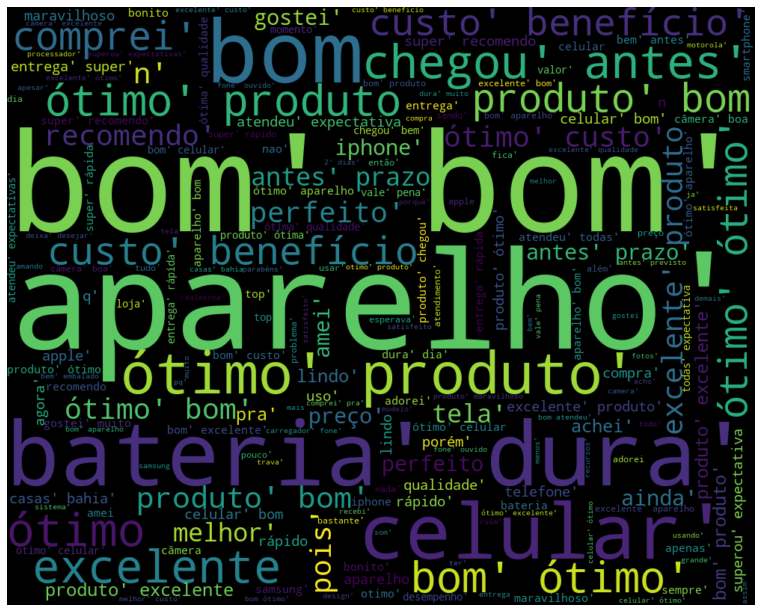

In [3]:
stopwordsNltk = nltk.corpus.stopwords.words('portuguese')

words = []
for i in df.COMMENT_TEXT:
    for p in i.lower().split():
        if p not in stopwordsNltk:
            words.append(p)
            
words = str(words)

wordcloud = WordCloud(width = 1000, height= 800, margin = 0).generate(words)
plt.figure(figsize=(20,11))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.margins(x=0, y=0)

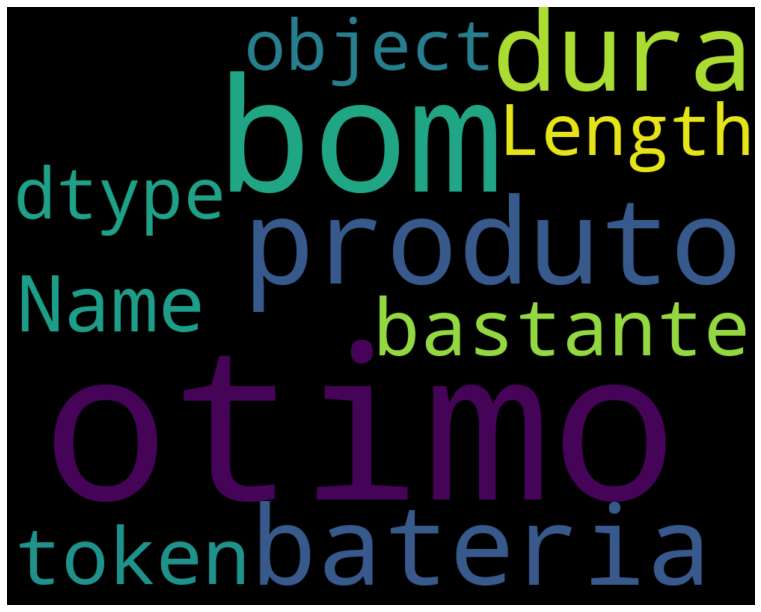

In [4]:
words = str(df2['token'])

wordcloud = WordCloud(width = 1000, height= 800, margin = 0).generate(words)
plt.figure(figsize=(20,11))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.margins(x=0, y=0)